# 📊 Customer Churn Prediction (Telecom)

## 🎯 Objective
Predict customer churn using machine learning and identify high-risk customers.

## ✅ Steps Covered:
- Data Loading
- Exploratory Data Analysis
- Feature Engineering
- Data Preprocessing
- Model Training (XGBoost)
- Model Evaluation
- Feature Importance
- Business Insights

In [52]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost
from xgboost import XGBClassifier

# Display settings
pd.set_option('display.max_columns', None)

In [33]:
# Load dataset (adjust path if needed)
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Preview data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [37]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


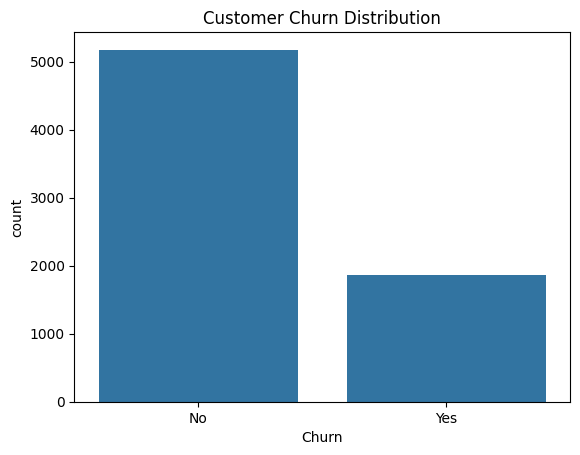

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [38]:
# Distribution of churn
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

# Percentage
(df['Churn'].value_counts(normalize=True) * 100)

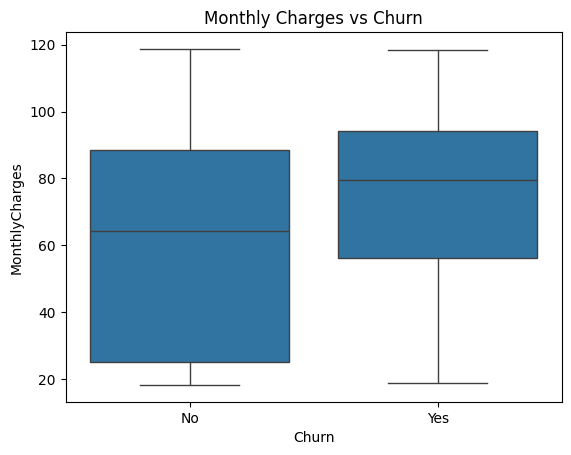

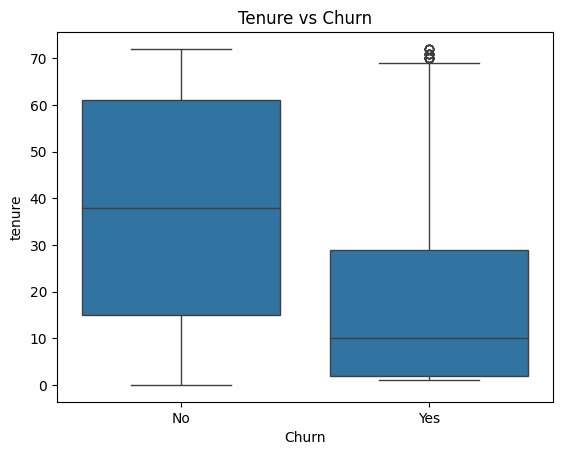

In [39]:
# Monthly charges vs churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# Tenure vs churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

In [40]:
def create_features(df):
    """
    Create additional features to improve model performance
    """
    df = df.copy()

    # 1. Price per tenure (higher = expensive early users)
    df['price_tenure_ratio'] = df['MonthlyCharges'] / (df['tenure'] + 1)

    # 2. Total services subscribed
    service_cols = [
        'PhoneService', 'InternetService', 'OnlineSecurity',
        'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies'
    ]
    df['total_services'] = (df[service_cols] == 'Yes').sum(axis=1)

    # 3. Internet users without security
    df['internet_no_protection'] = (
        (df['InternetService'] != 'No') &
        (df['OnlineSecurity'] == 'No') &
        (df['TechSupport'] == 'No')
    ).astype(int)

    # 4. Tenure segmentation
    df['tenure_segment'] = pd.cut(
        df['tenure'],
        bins=[0, 12, 24, 60, 100],
        labels=['<1yr', '1-2yr', '2-5yr', '>5yr']
    )

    # 5. Senior with dependents
    df['senior_with_dependents'] = (
        (df['SeniorCitizen'] == 1) &
        (df['Dependents'] == 'Yes')
    ).astype(int)

    return df

In [41]:
def preprocess_data(df):
    """
    Clean and prepare data for modeling
    """
    df = df.copy()

    # Fix TotalCharges column (convert to numeric)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # Fill missing values safely
    df['TotalCharges'] = df['TotalCharges'].fillna(0)

    # Convert target variable
    y = (df['Churn'] == 'Yes').astype(int)

    # Drop unnecessary columns
    X = df.drop(columns=['Churn', 'customerID'], errors='ignore')

    # Apply feature engineering
    X = create_features(X)

    # Convert categorical variables into numeric (One-hot encoding)
    X = pd.get_dummies(X, drop_first=True)

    return X, y

In [42]:
X, y = preprocess_data(df)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 37)
y shape: (7043,)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [44]:
# Scale features for better convergence
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
from xgboost import XGBClassifier

# XGBoost Model 
model = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=3,  # handles imbalance
    random_state=42
)

# Train model (NOTE: use NON-scaled data for XGBoost ✅)
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [51]:
y_pred = model.predict(X_test)

In [47]:
print("✅ Accuracy:", accuracy_score(y_test, y_pred))

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

✅ Accuracy: 0.8055358410220014

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.54      0.59       373

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



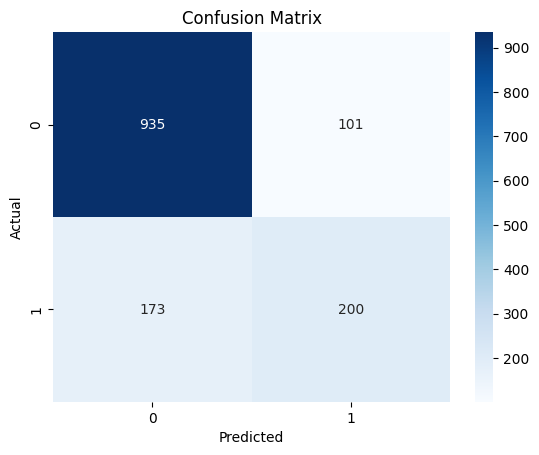

In [48]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

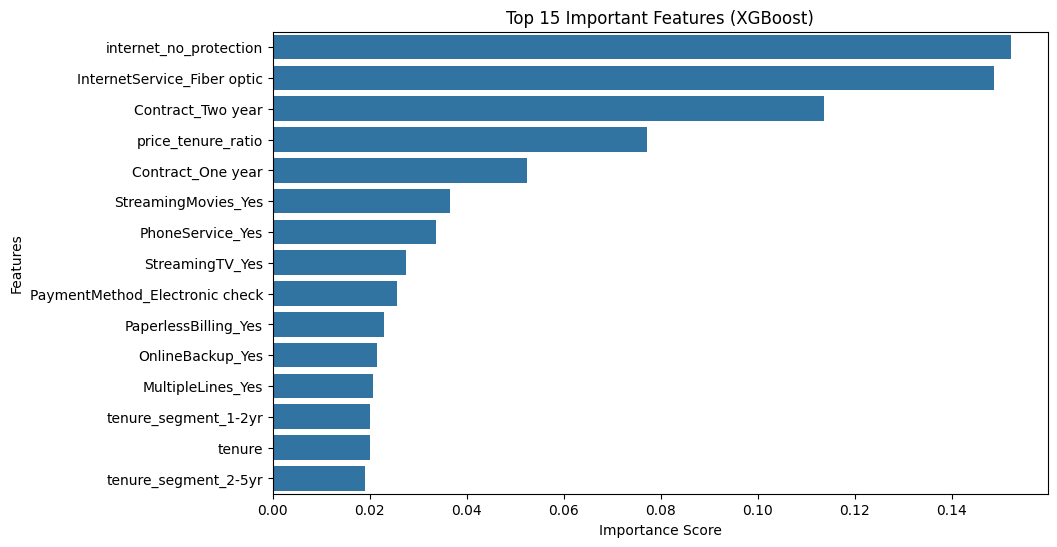

In [53]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance)

plt.title("Top 15 Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## 📈 Business Insights

### 🔍 Key Drivers of Churn:
- Month-to-month contracts
- High monthly charges
- Low tenure (new customers)
- Lack of security services

### 💡 Business Recommendations:
- Offer discounts for high-paying users
- Improve onboarding for new customers
- Promote long-term contracts
- Bundle security services

✅ Expected Impact:
- Reduce churn rate
- Increase customer lifetime value
- Improve retention strategies